In [1]:
from google.colab import files
uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('netflix_titles.csv')
print(df.shape)
df.head()

(8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
#  1. Basic Info
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Shape: (8807, 12)

Column Names:
 ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Data Types:
 show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Missing Values:
 show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [5]:
#  2. Data Cleaning
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df.fillna({'director': 'Unknown', 'cast': 'Unknown', 'country': 'Unknown'}, inplace=True)


/tmp/ipykernel_3298/99707556.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')


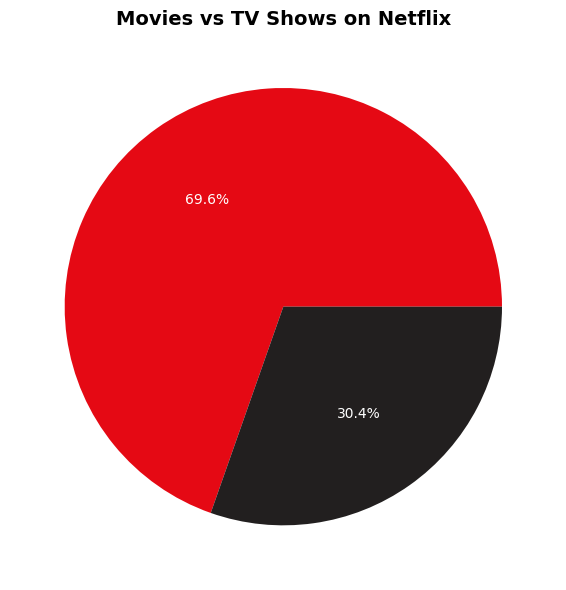

In [6]:
# 3. Movies vs TV Shows
plt.figure(figsize=(6,6))
df['type'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#E50914','#221F1F'],
                                    textprops={'color':'white'})
plt.title('Movies vs TV Shows on Netflix', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.savefig('plot1_type_distribution.png', dpi=150)
plt.show()

/tmp/ipykernel_3298/2629074559.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', order=order, palette='Reds_r')


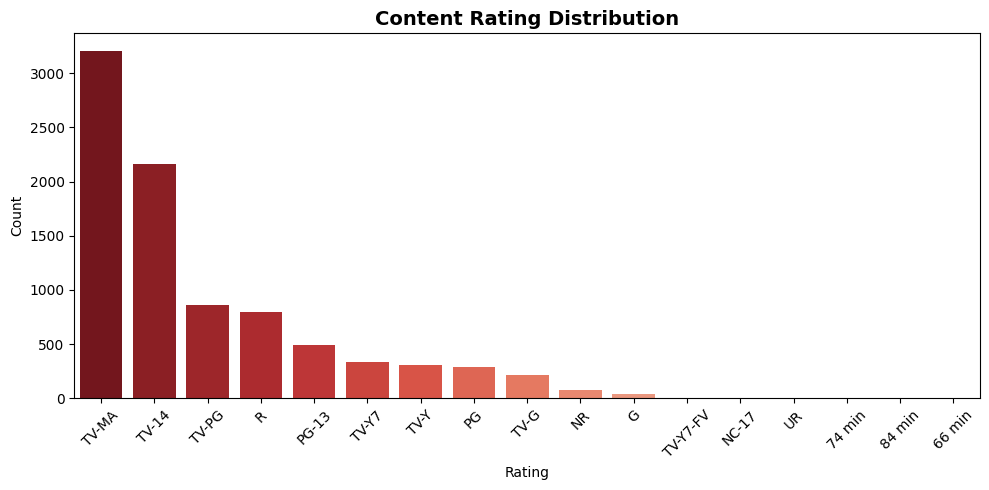

In [7]:
# 4. Ratings Distribution
plt.figure(figsize=(10,5))
order = df['rating'].value_counts().index
sns.countplot(data=df, x='rating', order=order, palette='Reds_r')
plt.title('Content Rating Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot2_ratings.png', dpi=150)
plt.show()

/tmp/ipykernel_3298/3602687193.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='Reds_r')


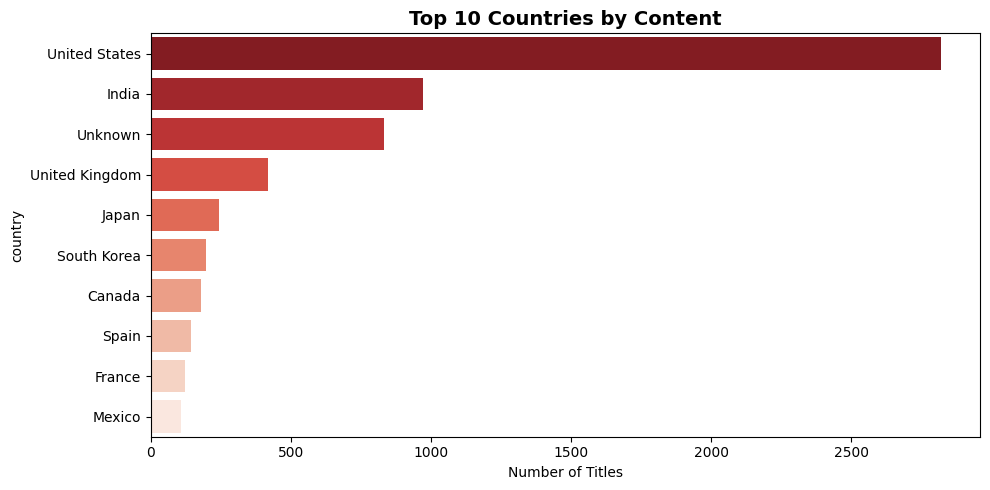

In [8]:
#  5. Top 10 Countries
top_countries = df['country'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Reds_r')
plt.title('Top 10 Countries by Content', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles')
plt.tight_layout()
plt.savefig('plot3_countries.png', dpi=150)
plt.show()


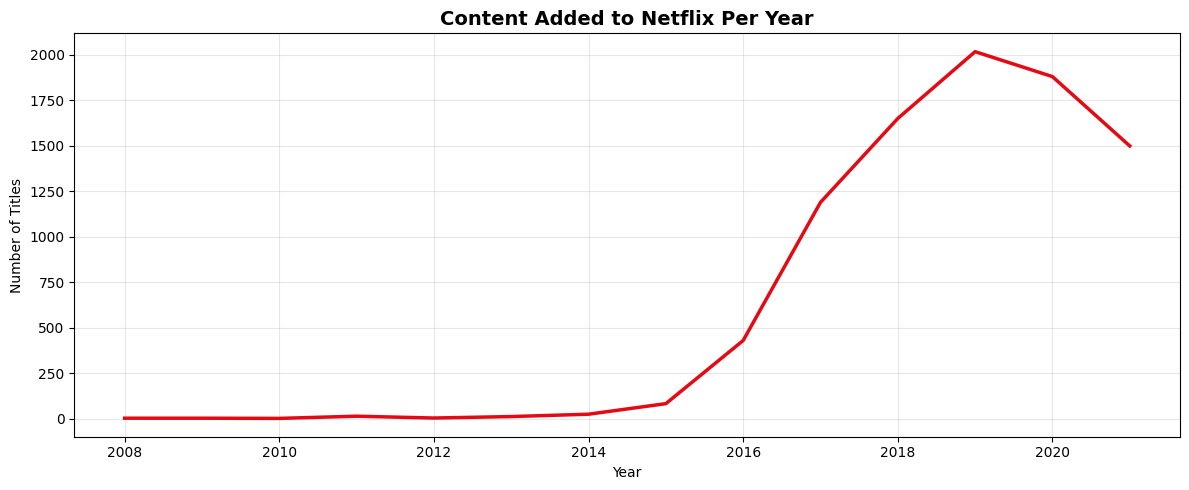

In [9]:
#  6. Content Added Per Year
plt.figure(figsize=(12,5))
df['year_added'].value_counts().sort_index().plot(kind='line', color='#E50914', linewidth=2.5)
plt.title('Content Added to Netflix Per Year', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot4_yearly_trend.png', dpi=150)
plt.show()

/tmp/ipykernel_3298/1051350325.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='Reds_r')


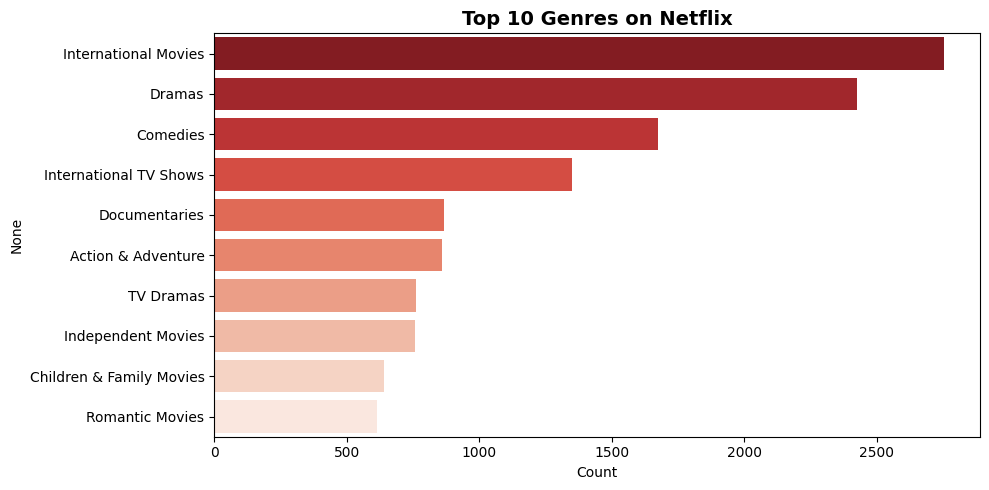

In [10]:
# 7. Top 10 Genres
from collections import Counter
genres = df['listed_in'].str.split(',').explode().str.strip()
top_genres = pd.Series(Counter(genres)).sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='Reds_r')
plt.title('Top 10 Genres on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.tight_layout()
plt.savefig('plot5_genres.png', dpi=150)
plt.show()

<Figure size 1200x500 with 0 Axes>

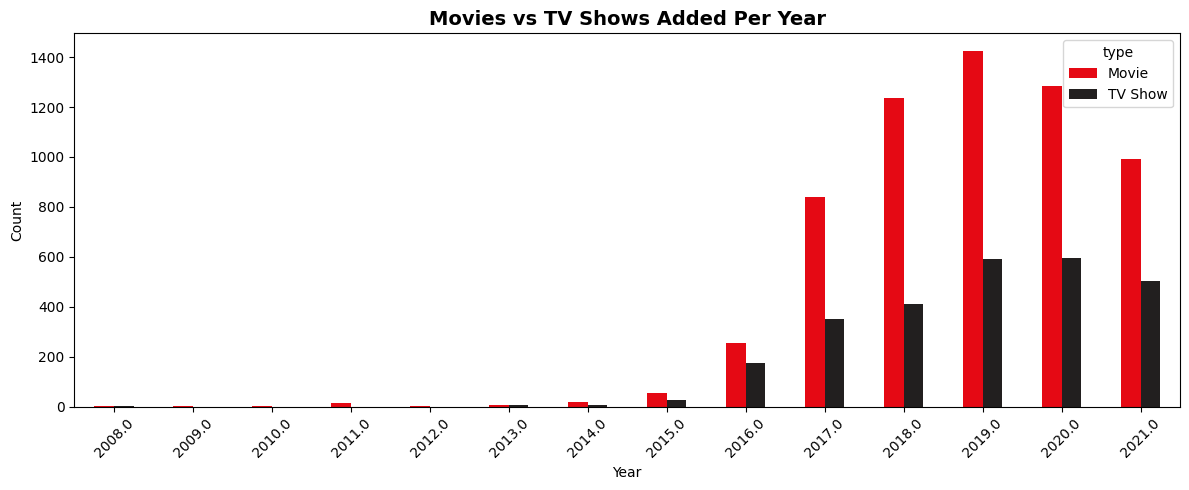

In [11]:
#  8. Movies vs TV Shows by Year
plt.figure(figsize=(12,5))
df.groupby(['year_added','type']).size().unstack().plot(
    kind='bar', color=['#E50914','#221F1F'], figsize=(12,5))
plt.title('Movies vs TV Shows Added Per Year', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot6_type_by_year.png', dpi=150)
plt.show()

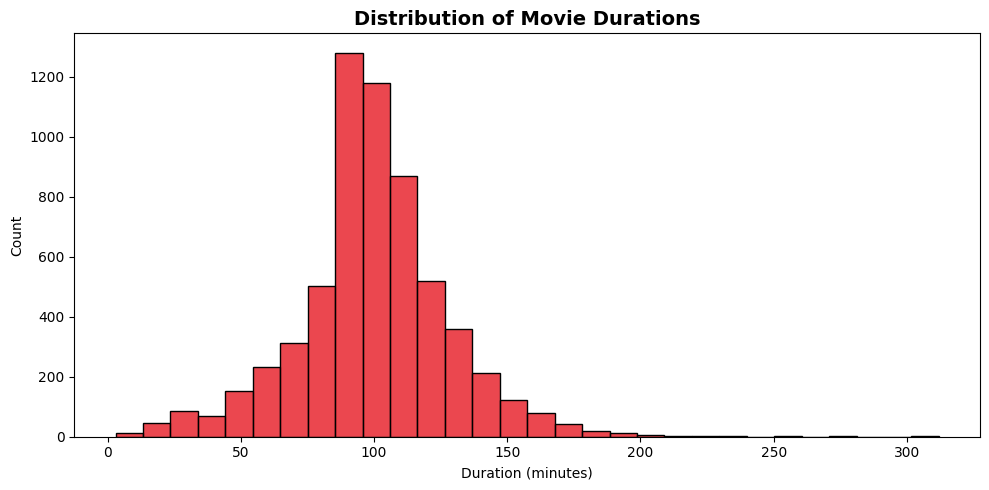

Average Movie Duration: 99.58 minutes
Longest Movie: Black Mirror: Bandersnatch
Shortest Movie: Silent


In [12]:
# 9. Duration Analysis (Movies only)
movies = df[df['type'] == 'Movie'].copy()
movies['duration_min'] = movies['duration'].str.replace(' min','').astype(float)

plt.figure(figsize=(10,5))
sns.histplot(movies['duration_min'].dropna(), bins=30, color='#E50914')
plt.title('Distribution of Movie Durations', fontsize=14, fontweight='bold')
plt.xlabel('Duration (minutes)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plot7_movie_duration.png', dpi=150)
plt.show()

print("Average Movie Duration:", round(movies['duration_min'].mean(), 2), "minutes")
print("Longest Movie:", movies.loc[movies['duration_min'].idxmax(), 'title'])
print("Shortest Movie:", movies.loc[movies['duration_min'].idxmin(), 'title'])

In [13]:
#  10. Summary Insights
print("=" * 45)
print("        NETFLIX DATA — KEY INSIGHTS")
print("=" * 45)
print(f"Total Titles:         {df.shape[0]}")
print(f"Total Movies:         {df[df['type']=='Movie'].shape[0]}")
print(f"Total TV Shows:       {df[df['type']=='TV Show'].shape[0]}")
print(f"Countries Covered:    {df['country'].nunique()}")
print(f"Year Range:           {int(df['release_year'].min())} - {int(df['release_year'].max())}")
print(f"Most Common Rating:   {df['rating'].value_counts().index[0]}")
print(f"Top Country:          {df['country'].value_counts().index[0]}")
print(f"Peak Year Added:      {int(df['year_added'].value_counts().index[0])}")
print("=" * 45)

        NETFLIX DATA — KEY INSIGHTS
Total Titles:         8807
Total Movies:         6131
Total TV Shows:       2676
Countries Covered:    749
Year Range:           1925 - 2021
Most Common Rating:   TV-MA
Top Country:          United States
Peak Year Added:      2019
